In [1]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_5729/3787181349.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 18 sessions, 366 files


In [3]:
def plot_fooof_and_residuals(freqs, mean_psd, trial_psds=None, freq_range=[1, 200], peak_width_limits=[2.0, 12.0]):
    """
    Fits a FOOOF model to a mean PSD and plots the fit alongside the residuals 
    (distance from the aperiodic fit).
    
    Parameters:
    ----------
    freqs : 1D numpy array
        Array of frequency values.
    mean_psd : 1D numpy array
        Array of power values (linear scale, FOOOF will log-transform internally).
    trial_psds : list or 2D numpy array, default=None
        Array of power values for individual trials to compute error bars (standard deviation).
    freq_range : list, default=[1, 200]
        Frequency range to fit the model over.
    peak_width_limits : list, default=[2.0, 12.0]
        Limits on possible peak widths.
        
    Returns:
    -------
    fm : FOOOF object
        The fitted FOOOF model in case you want to extract specific parameters later.
    """
    # Initialize the FOOOF model (SpecParam)
    fm = FOOOF(peak_width_limits=peak_width_limits, max_n_peaks=6, min_peak_height=0.1)
    
    # Fit the model
    fm.fit(freqs, mean_psd, freq_range)
    
    # Create the figure with 2 side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- Plot 1: Standard FOOOF Fit ---
    fm.plot(add_legend=True, ax=axes[0])
    axes[0].set_title('FOOOF Fit to Raw PSD', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # --- Plot 2: Distance from Aperiodic Fit ---
    # Retrieve the fitted frequency range, log power spectrum, and the aperiodic fit
    fit_freqs = fm.freqs
    log_power_spectrum = fm.power_spectrum
    aperiodic_fit = fm._ap_fit
    
    # Calculate the difference (actual signal minus the 1/f background)
    residuals = log_power_spectrum - aperiodic_fit
    
    axes[1].plot(fit_freqs, residuals, color='firebrick', linewidth=2, label='Mean Power Above 1/f')
    
    # Add error bars if trial data is provided
    if trial_psds is not None:
        # Create a mask for the frequency range
        mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
        trial_psds_fit = np.array(trial_psds)[:, mask]
        
        # Calculate residuals for each trial
        log_trial_psds = np.log10(trial_psds_fit)
        trial_residuals = log_trial_psds - aperiodic_fit
        std_residuals = np.std(trial_residuals, axis=0)
        
        axes[1].fill_between(
            fit_freqs, 
            residuals - std_residuals, 
            residuals + std_residuals, 
            color='firebrick', 
            alpha=0.2, 
            label='±1 SD'
        )
    
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('log(Power) Distance from Aperiodic')
    axes[1].set_title('High-Gamma / Periodic Components', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fm

Processed 366 full continuous trials (State 3).


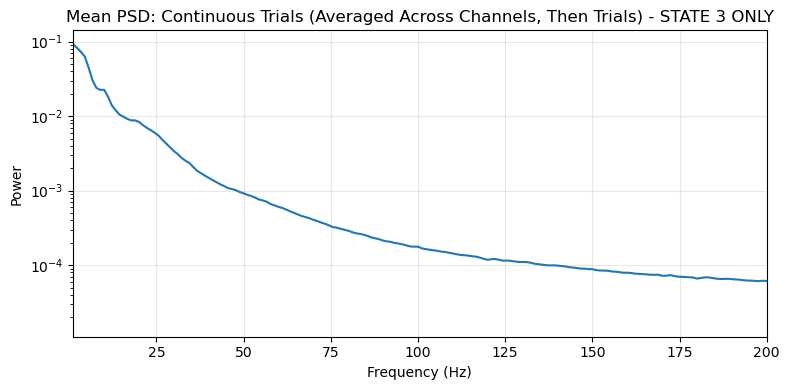

In [23]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 900 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_3_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 3:
                state_3_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_3_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd = np.mean(all_trial_psds, axis=0)

# Overwrite trial_psds so the FOOOF ±1 SD cell directly below continues to work!
trial_psds = all_trial_psds 

plt.figure(figsize=(8, 4))
plt.semilogy(freqs_ref, mean_psd)
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Mean PSD: Continuous Trials (Averaged Across Channels, Then Trials) - STATE 3 ONLY")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

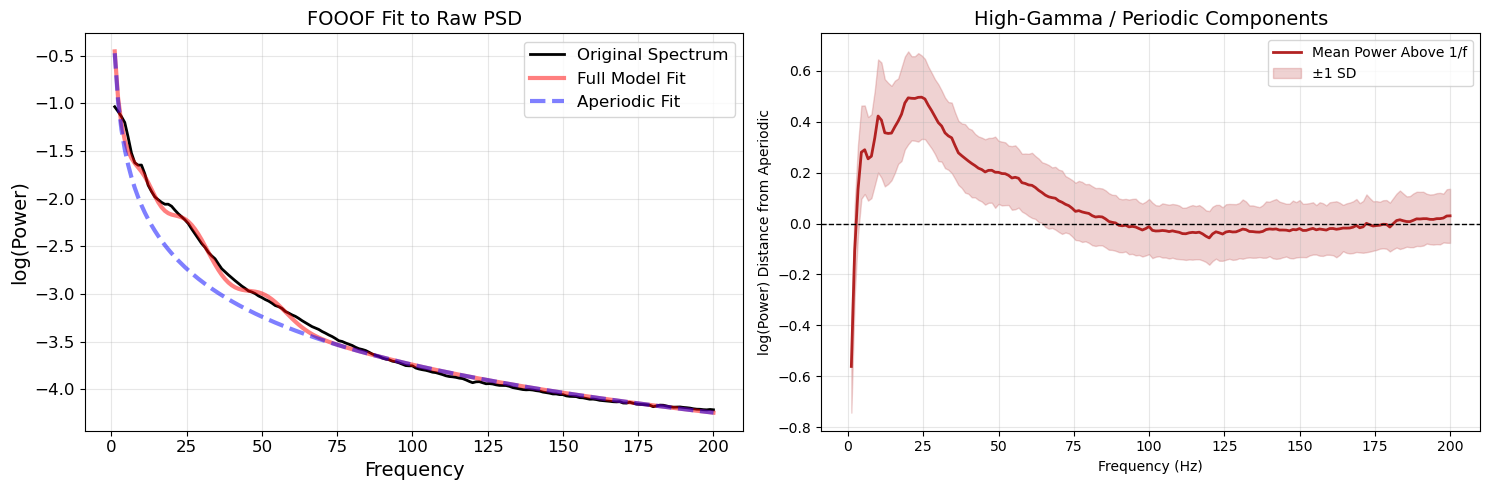

In [24]:
freq_range=[1, 200]
fm = plot_fooof_and_residuals(
    freqs=freqs_ref,              # The freq array returned by scipy.signal.welch
    mean_psd=mean_psd,            # Your averaged PSD (linear scale, not log)
    trial_psds=trial_psds,        # Individual trials for standard deviation calculation
    freq_range=[1, 200],          # Trims frequencies outside this window before fitting
    peak_width_limits=[2.0, 15.0] # High Gamma peaks are wide! Don't cap it at 8Hz.
)

In [26]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 900 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_1_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 1:
                state_1_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_1_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref_1 = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd_1 = np.mean(all_trial_psds, axis=0)

Processed 366 full continuous trials (State 3).


In [27]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 900 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_3_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 3:
                state_3_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_3_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref_2 = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd_3 = np.mean(all_trial_psds, axis=0)

Processed 366 full continuous trials (State 3).


In [28]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 900 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_2_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 2:
                state_2_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_2_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref_3 = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd_2 = np.mean(all_trial_psds, axis=0)

Processed 366 full continuous trials (State 3).


In [29]:
# Data already loaded earlier in your notebook
all_data = all_long_combined  # or short_data

fs = 1000
n_channels = 128
nperseg = 900 # 1.5-second Welch window for better than 1Hz resolution

all_trial_psds = [] 
freqs_ref = None

for subj_files in all_data.values():
    for mat_file in subj_files.values():
        broadband = mat_file.get("BroadbandData")
        task_state = mat_file.get("TaskState")
            
        # TaskState might be 2D in MATLAB (e.g., shape (N, 1)), so let's guarantee it's a flat 1D list 
        task_state_flat = np.array(task_state).flatten()

        # Filter out bins that do NOT correspond to State 3
        state_4_bins = []
        for i in range(len(broadband)):
            if task_state_flat[i] == 4:
                state_4_bins.append(broadband[i])
            
        # 1. CONCATENATE all the State 3 bins together into ONE continuous trial.
        full_trial_signal = np.concatenate(state_3_bins, axis=1) 
                    
        # 2. Calculate PSD on the full concatenated trial (for each channel)
        ch_psds = []
        for ch in range(n_channels):
                
            freqs, psd = welch(full_trial_signal[ch], fs=fs, nperseg=nperseg)
            ch_psds.append(psd)
            
        # If the trial was too short for Welch and ch_psds is empty, skip
        if len(ch_psds) == 0:
            continue
            
        # 3. Average across all 128 channels for THIS single trial
        trial_mean_psd = np.mean(ch_psds, axis=0) 
        all_trial_psds.append(trial_mean_psd)
        
        if freqs_ref is None:
            freqs_ref_4 = freqs

print(f"Processed {len(all_trial_psds)} full continuous trials (State 3).")

# 4. Average across all trials to get final spectrum
mean_psd_4 = np.mean(all_trial_psds, axis=0)

Processed 366 full continuous trials (State 3).


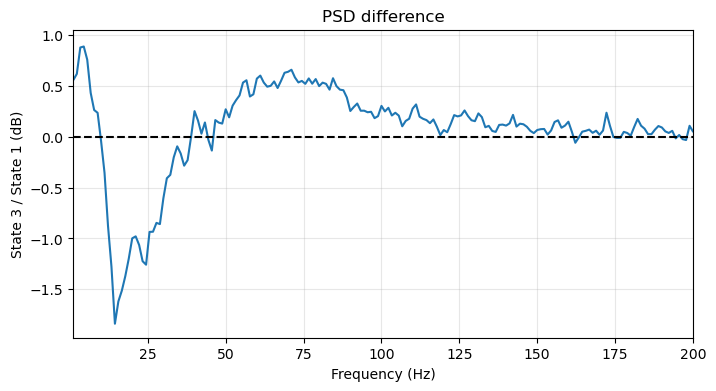

In [32]:
plt.figure(figsize=(8,4))
plt.plot(freqs_ref_1, 10 * np.log10(mean_psd_3 / mean_psd_1))
plt.axhline(0, color='k', linestyle='--')
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("State 3 / State 1 (dB)")
plt.title("PSD difference")
plt.grid(alpha=0.3)
plt.show()

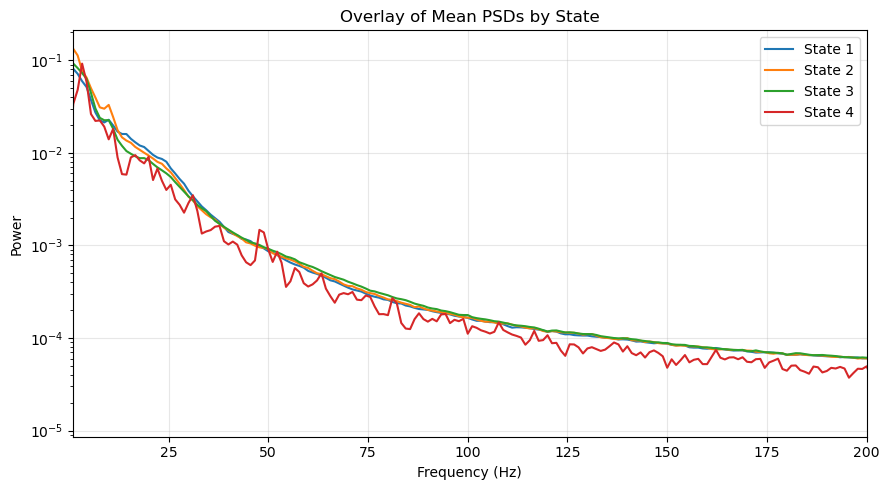

In [ ]:
plt.figure(figsize=(9, 5))
plt.semilogy(freqs_ref_1, mean_psd_1, label='State 1')
plt.semilogy(freqs_ref_2, mean_psd_2, label='State 2')
plt.semilogy(freqs_ref_3, mean_psd_3, label='State 3')
plt.semilogy(freqs_ref_4, mean_psd_4, label='State 4')
plt.xlim(1, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Overlay of Mean PSDs by State")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



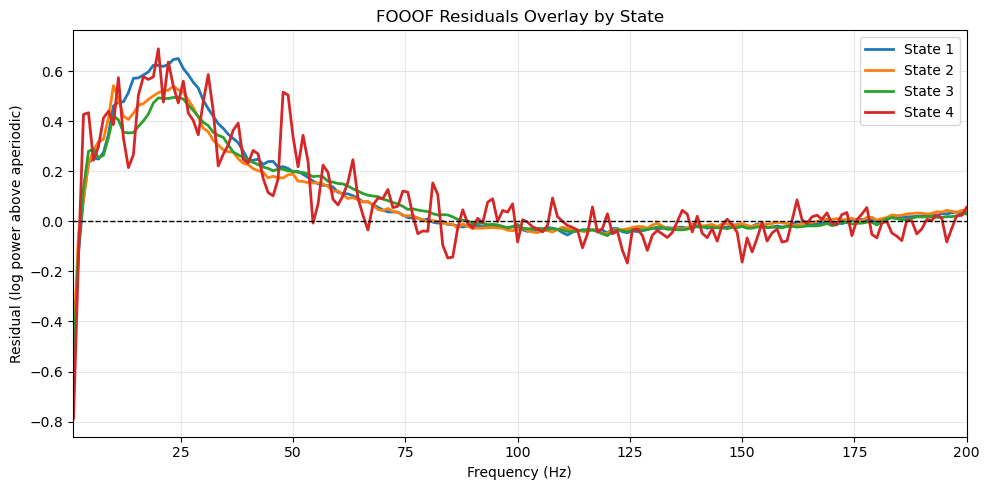

In [30]:
freq_range = [1, 200]
peak_width_limits = [2.0, 15.0]

state_psds = {
    "State 1": mean_psd_1,
    "State 2": mean_psd_2,
    "State 3": mean_psd_3,
    "State 4": mean_psd_4,
}

# Use one shared frequency vector (same fs/nperseg should make these identical)
freqs_common = freqs_ref_1

plt.figure(figsize=(10, 5))

for label, psd in state_psds.items():
    fm = FOOOF(
        peak_width_limits=peak_width_limits,
        max_n_peaks=6,
        min_peak_height=0.1,
        verbose=False
    )
    fm.fit(freqs_common, psd, freq_range)

    # Residual = log10(power) - aperiodic fit
    residuals = fm.power_spectrum - fm._ap_fit
    plt.plot(fm.freqs, residuals, linewidth=2, label=label)

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlim(freq_range)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Residual (log power above aperiodic)")
plt.title("FOOOF Residuals Overlay by State")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()